# TEMPO quickstart

This notebook follows the OQuPy quickstart setup using `quante.tensornetwork.opensystem` and compares the current `backend="mps"` result with OQuPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quante.tensornetwork.opensystem.tempo import *

import quante as qt
import quante.tensornetwork.opensystem as qto
from quante.generate.matrix import pauli_matrix

sigma_x = pauli_matrix("X")
sigma_z = pauli_matrix("Z")

up = pauli_matrix("u")
rho0 = up @ up.conj().T

Omega = 1.0
alpha = 0.3
omega_cutoff = 5.0

system = qto.System(0.5 * Omega * sigma_x)
correlation = qto.PowerLawSpectralDensity(alpha=alpha, zeta=1.0, cutoff=omega_cutoff)
bath = qto.Bath(0.5 * sigma_z, correlation)
params = qto.TempoParams(dt=0.1, tcut=3.0, epsrel=1e-4, trunc_cut=1e-8, apply_mpo_method='zip_up',normalize=False)
ts = np.arange(0.0, 15.0 + params.dt / 2, params.dt)
te = qto.TempoEngine(system,bath,params,rho0,ts,)
res = te.run(measure=0.5*sigma_z)

100%|##########| 151/151 [00:02<00:00, 62.88it/s]


--> TEMPO computation:
100.0%  150 of  150 [########################################] 00:00:04
Elapsed time: 4.5s


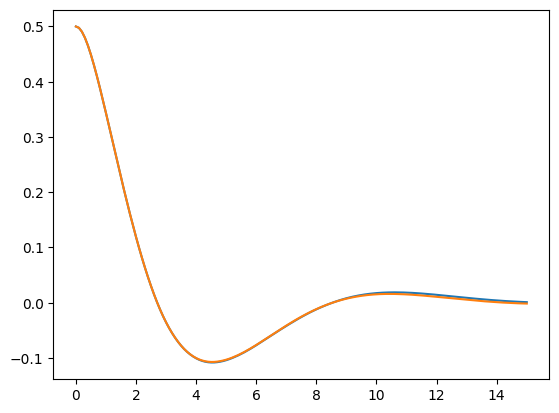

In [2]:
import oqupy
import numpy as np
import matplotlib.pyplot as plt

sigma_x = oqupy.operators.sigma("x")
sigma_y = oqupy.operators.sigma("y")
sigma_z = oqupy.operators.sigma("z")
up_density_matrix = oqupy.operators.spin_dm("z+")
down_density_matrix = oqupy.operators.spin_dm("z-")

Omega = 1.0
omega_cutoff = 5.0
alpha = 0.3

oqupy_system = oqupy.System(0.5 * Omega * sigma_x)
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential')
oqupy_bath = oqupy.Bath(0.5 * sigma_z, correlations)
tempo_parameters = oqupy.TempoParameters(dt=0.1, tcut=3.0, epsrel=10**(-4))
l = 150
dt = 0.1
dynamics = oqupy.tempo_compute(system=oqupy_system,
                               bath=oqupy_bath,
                               initial_state=up_density_matrix,
                               start_time=0.0,
                               end_time=dt*l,
                               parameters=tempo_parameters,
                               unique=False)
t, s_z = dynamics.expectations(0.5*sigma_z, real=True)
plt.plot(t, np.real(res))
plt.plot(t, np.real(s_z))